Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loading data...


/scratch/ipykernel_2944145/3612480245.py:37: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  orthos = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz", sep="\t")


Processing ortholog data...
Shared orthologous genes: 4688
Creating analysis directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11
Created: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/data
Created: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/figures
Created: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results

Analysis folder created successfully!
Base directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11

Saving processed datasets...

Creating plots...
Figure saved: 102822_splice_motif_usage_comparison


<Figure size 800x500 with 0 Axes>

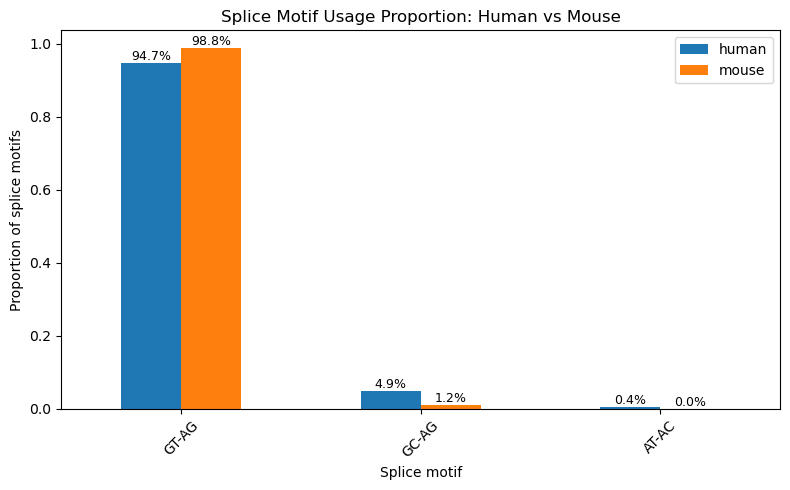

Figure saved: 102832_donor_acceptor_read_distributions


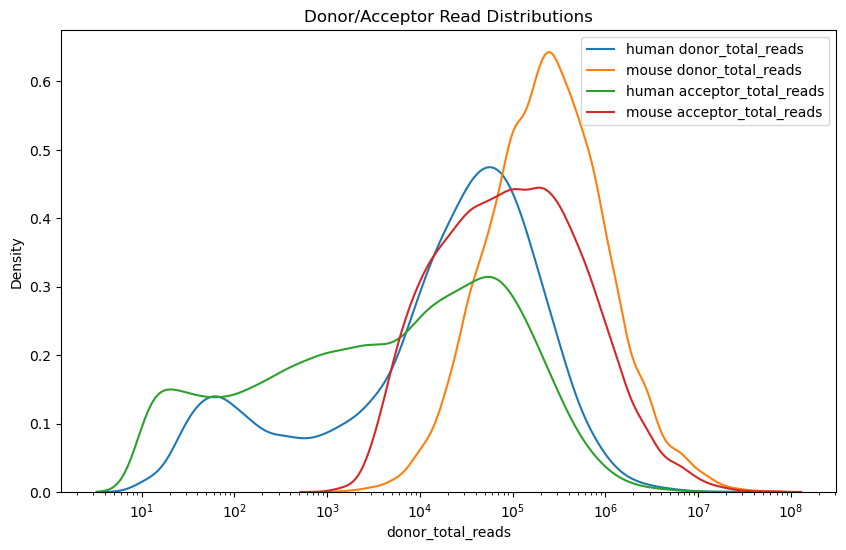

Figure saved: 102841_junction_count_per_gene


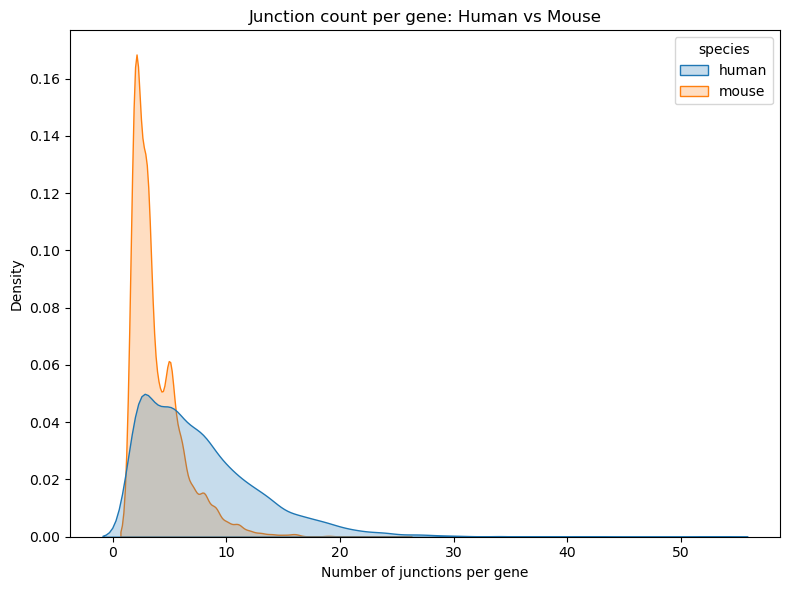


Analysis setup complete!
All files saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11
Summary statistics saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/summary_statistics.csv

Path variables for future use:
  base_dir = '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11'
  data_dir = '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/data'
  figures_dir = '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/figures'
  results_dir = '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results'


In [1]:
import os
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import gffutils

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *

from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from pyfaidx import Fasta
from Bio.Seq import Seq

# Load genome
human_genome = Fasta("/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/GRCh38.primary_assembly.genome.fa")
mouse_genome = Fasta("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/fasta/genome.fa")

# Load data first
MOUSE = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-04-26_19-55-26.txt.gz"
MOUSE_EXTENDED = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-04-19_17-37-00.txt.gz"
HUMAN = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/stella_gtf/TMS_atse_file_unanno_also_2025-05-11_06-23-05.txt.gz"

print("Loading data...")
mouse_atse = pd.read_csv(MOUSE, sep="\t")
human_atse = pd.read_csv(HUMAN, sep="\t")

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

human_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/v45hg38"
db_human = gffutils.FeatureDB(human_db_file, keep_order=True)

orthos = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz", sep="\t")

# Process ortholog data
print("Processing ortholog data...")
o_genes = orthos[["Gene stable ID", "Mouse gene stable ID", "Last common ancestor with Mouse", 
                  "Mouse homology type", "Mouse gene name", "Gene name"]].drop_duplicates()
o_genes = o_genes[o_genes["Mouse homology type"].isin(["ortholog_one2one"])]

# Clean gene IDs
mouse_atse["gene_id"] = mouse_atse["gene_id"].str.split(".").str[0]
human_atse["gene_id"] = human_atse["gene_id"].str.split(".").str[0]

# Prepare for merging
mouse_atse["Mouse gene stable ID"] = mouse_atse["gene_id"]
human_atse["Gene stable ID"] = human_atse["gene_id"]
mouse_atse["Mouse gene name"] = mouse_atse["gene_name"]
human_atse["Gene name"] = human_atse["gene_name"]

# Merge with ortholog data
mouse_atse = mouse_atse.merge(o_genes, on=["Mouse gene stable ID", "Mouse gene name"])
human_atse = human_atse.merge(o_genes, on=["Gene stable ID"])

# Filter for shared genes
human_atse = human_atse[human_atse["Mouse gene stable ID"].isin(mouse_atse["Mouse gene stable ID"])]
mouse_atse = mouse_atse[mouse_atse["Gene stable ID"].isin(human_atse["Gene stable ID"])]

# Apply filters (NOTE: ONLY KEEPING ATSES WITH 3 JUNCTIONS OR LESS)
# For now, to just try and find conserved simle exon skipping or alt 5'/3' splicing
num_junctions_filter = 3
human_atse = human_atse[human_atse["num_junctions"] <= 3]
mouse_atse = mouse_atse[mouse_atse["num_junctions"] <= 3]

human_atse = human_atse[human_atse["Mouse homology type"] == "ortholog_one2one"]
mouse_atse = mouse_atse[mouse_atse["Mouse homology type"] == "ortholog_one2one"]

# Remove genes with multiple strands
gene_strand_info = human_atse.groupby('gene_id')['strand'].nunique().reset_index()
genes_with_multiple_strands = gene_strand_info[gene_strand_info['strand'] > 1]
human_atse = human_atse[~human_atse["gene_id"].isin(genes_with_multiple_strands["gene_id"])]

# Final filtering
human_atse = human_atse[human_atse["Mouse gene stable ID"].isin(mouse_atse["Mouse gene stable ID"])]
mouse_atse = mouse_atse[mouse_atse["Mouse gene stable ID"].isin(human_atse["Mouse gene stable ID"])]

# Calculate shared genes BEFORE creating README
mouse_orthologs = mouse_atse[mouse_atse['Mouse homology type'] == 'ortholog_one2one']
human_orthologs = human_atse[human_atse['Mouse homology type'] == 'ortholog_one2one']

shared_genes = set(mouse_orthologs['gene_name']).intersection(
    set(human_orthologs['Mouse gene name'])
)

print(f"Shared orthologous genes: {len(shared_genes)}")

# NOW create the analysis folder
base_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation"
current_date = datetime.now().strftime("%Y-%m-%d")
analysis_dir = os.path.join(base_dir, f"cross_species_conservation_analysis_{current_date}")

# Create subdirectories
subdirs = ["data", "figures", "results"]

print(f"Creating analysis directory: {analysis_dir}")
os.makedirs(analysis_dir, exist_ok=True)

for subdir in subdirs:
    subdir_path = os.path.join(analysis_dir, subdir)
    os.makedirs(subdir_path, exist_ok=True)
    print(f"Created: {subdir_path}")

# Define paths for easy access
paths = {
    'base': analysis_dir,
    'data': os.path.join(analysis_dir, "data"),
    'figures': os.path.join(analysis_dir, "figures"),
    'results': os.path.join(analysis_dir, "results")
}

# Create README with correct variables
readme_content = f"""# Cross-Species Splicing Conservation Analysis
Analysis Date: {current_date}

## Directory Structure:
- data/: Processed datasets (filtered ATSE files, ortholog mappings, etc.)
- figures/: All plots and visualizations
- results/: Analysis results, conservation tables, summary statistics

## Data Sources:
- Mouse ATSE: {MOUSE}
- Human ATSE: {HUMAN}
- Orthologs: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz

## Analysis Goals:
1. Compare splice motif usage between mouse and human
2. Analyze junction count distributions
3. Identify conserved splice junctions in one-to-one orthologs
4. Cross-species aging factor conservation analysis

## Key Statistics:
- Shared orthologous genes: {len(shared_genes)}
- Mouse junctions: {len(mouse_atse)}
- Human junctions: {len(human_atse)}
- Mouse genes: {mouse_atse['gene_id'].nunique()}
- Human genes: {human_atse['gene_id'].nunique()}
"""

with open(os.path.join(analysis_dir, "README.md"), "w") as f:
    f.write(readme_content)

print(f"\nAnalysis folder created successfully!")
print(f"Base directory: {analysis_dir}")

# Save datasets
print("\nSaving processed datasets...")
mouse_atse.to_csv(os.path.join(paths['data'], "mouse_atse_filtered_orthologs.csv"), index=False)
human_atse.to_csv(os.path.join(paths['data'], "human_atse_filtered_orthologs.csv"), index=False)
orthos.to_csv(os.path.join(paths['data'], "ortholog_mappings.csv"), index=False)

# Helper function to save figures
def save_figure(fig_name, description=""):
    """Helper function to save figures with timestamp."""
    timestamp = datetime.now().strftime("%H%M%S")
    filename = f"{timestamp}_{fig_name}"
    
    # Save as PDF
    pdf_path = os.path.join(paths['figures'], f"{filename}.pdf")
    plt.savefig(pdf_path, dpi=300, bbox_inches='tight')
    
    # Save as PNG
    png_path = os.path.join(paths['figures'], f"{filename}.png")
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    
    print(f"Figure saved: {filename}")
    return pdf_path

# Create and save plots
print("\nCreating plots...")

# 1. Splice motif usage
human_motifs = Counter(human_atse["splice_motif"])
mouse_motifs = Counter(mouse_atse["splice_motif"])
motif_df = pd.DataFrame([human_motifs, mouse_motifs], index=["human", "mouse"]).fillna(0)
motif_df_prop = motif_df.div(motif_df.sum(axis=1), axis=0)

plt.figure(figsize=(8, 5))
ax = motif_df_prop.T.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Proportion of splice motifs")
ax.set_xlabel("Splice motif")
ax.set_title("Splice Motif Usage Proportion: Human vs Mouse")
plt.xticks(rotation=45)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f"{height*100:.1f}%", 
                        (bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
save_figure("splice_motif_usage_comparison", "Comparison of splice motif proportions")
plt.show()

# 2. Donor/Acceptor read distributions
plt.figure(figsize=(10, 6))
for col in ["donor_total_reads", "acceptor_total_reads"]:
    sns.kdeplot(human_atse[col], label=f"human {col}", log_scale=True)
    sns.kdeplot(mouse_atse[col], label=f"mouse {col}", log_scale=True)
plt.legend()
plt.title("Donor/Acceptor Read Distributions")
save_figure("donor_acceptor_read_distributions", "Log-scale KDE plots of read counts")
plt.show()

# 3. Junction count per gene
human_counts = human_atse["gene_id"].value_counts()
mouse_counts = mouse_atse["gene_id"].value_counts()

human_df = human_counts.rename("junction_count").reset_index()
human_df["species"] = "human"
mouse_df = mouse_counts.rename("junction_count").reset_index()
mouse_df["species"] = "mouse"
combined_df = pd.concat([human_df, mouse_df], ignore_index=True)

plt.figure(figsize=(8, 6))
sns.kdeplot(data=combined_df, x="junction_count", hue="species", fill=True)
plt.xlabel("Number of junctions per gene")
plt.ylabel("Density")
plt.title("Junction count per gene: Human vs Mouse")
plt.tight_layout()
save_figure("junction_count_per_gene", "Distribution of junction counts per gene")
plt.show()

# Save summary statistics
summary_stats = {
    'analysis_date': current_date,
    'shared_orthologous_genes': len(shared_genes),
    'mouse_junctions_total': len(mouse_atse),
    'human_junctions_total': len(human_atse),
    'mouse_genes_total': mouse_atse['gene_id'].nunique(),
    'human_genes_total': human_atse['gene_id'].nunique()
}

summary_df = pd.Series(summary_stats)
summary_df.to_csv(os.path.join(paths['results'], "summary_statistics.csv"))

print(f"\nAnalysis setup complete!")
print(f"All files saved to: {analysis_dir}")
print(f"Summary statistics saved to: {os.path.join(paths['results'], 'summary_statistics.csv')}")

# Print the paths for reference
print("\nPath variables for future use:")
for key, path in paths.items():
    print(f"  {key}_dir = '{path}'")

In [2]:
# Export junction coordinates as BED files for UCSC liftover
import pandas as pd
import os

def parse_junction_id(junction_id):
    """Parse junction ID to extract coordinates."""
    parts = junction_id.split('_')
    chrom, start, end, strand = parts[0], int(parts[1]), int(parts[2]), parts[3]
    return chrom, start, end, strand

def create_mouse_junction_bed(mouse_atse_df, output_dir):
    """
    Create BED file for mouse junction coordinates.
    
    Args:
        mouse_atse_df: Mouse ATSE dataframe
        output_dir: Directory to save BED files
    
    Returns:
        Path to created BED file
    """
    
    print(f"Creating mouse junction BED file from {len(mouse_atse_df)} junctions...")
    
    bed_entries = []
    
    for idx, row in mouse_atse_df.iterrows():
        try:
            chrom, start, end, strand = parse_junction_id(row['junction_id'])
            
            # Create BED entry for the full junction
            # BED format: chrom, start, end, name, score, strand
            bed_entries.append({
                'chrom': chrom,
                'start': start,  # BED is 0-based, but junction coordinates are usually 1-based
                'end': end,
                'name': f"{row['junction_id']}_{row['gene_name']}_{row['event_id']}",
                'score': 0,
                'strand': strand,
                'junction_id': row['junction_id'],
                'gene_name': row['gene_name'],
                'event_id': row['event_id'],
                'gene_id': row['gene_id']
            })
            
        except Exception as e:
            print(f"Error parsing junction {row['junction_id']}: {e}")
            continue
    
    # Create DataFrame and save as BED
    bed_df = pd.DataFrame(bed_entries)
    
    # Sort by chromosome and position
    bed_df = bed_df.sort_values(['chrom', 'start'])
    
    # Create BED file (standard 6-column format for UCSC)
    bed_file_path = os.path.join(output_dir, "mouse_junctions_mm10.bed")
    
    # Write BED file (tab-separated, no header)
    with open(bed_file_path, 'w') as f:
        for _, row in bed_df.iterrows():
            f.write(f"{row['chrom']}\t{row['start']}\t{row['end']}\t{row['name']}\t{row['score']}\t{row['strand']}\n")
    
    # Also save the full annotation file for later matching
    annotation_file_path = os.path.join(output_dir, "mouse_junctions_annotations.csv")
    bed_df.to_csv(annotation_file_path, index=False)
    
    print(f"Mouse BED file created: {bed_file_path}")
    print(f"Mouse annotations saved: {annotation_file_path}")
    print(f"   Contains {len(bed_df)} junctions from {bed_df['gene_name'].nunique()} genes")
    
    return bed_file_path, annotation_file_path

def create_human_junction_bed(human_atse_df, output_dir):
    """
    Create BED file for human junction coordinates.
    
    Args:
        human_atse_df: Human ATSE dataframe
        output_dir: Directory to save BED files
    
    Returns:
        Path to created BED file
    """
    
    print(f"Creating human junction BED file from {len(human_atse_df)} junctions...")
    
    bed_entries = []
    
    for idx, row in human_atse_df.iterrows():
        try:
            chrom, start, end, strand = parse_junction_id(row['junction_id'])
            
            # Create BED entry for the full junction
            bed_entries.append({
                'chrom': chrom,
                'start': start,
                'end': end,
                'name': f"{row['junction_id']}_{row.get('Gene name', 'Unknown')}_{row['event_id']}",
                'score': 0,
                'strand': strand,
                'junction_id': row['junction_id'],
                'human_gene_name': row.get('Gene name', 'Unknown'),
                'mouse_gene_name': row.get('Mouse gene name', 'Unknown'),
                'event_id': row['event_id'],
                'gene_id': row['gene_id']
            })
            
        except Exception as e:
            print(f"Error parsing junction {row['junction_id']}: {e}")
            continue
    
    # Create DataFrame and save as BED
    bed_df = pd.DataFrame(bed_entries)
    
    # Sort by chromosome and position
    bed_df = bed_df.sort_values(['chrom', 'start'])
    
    # Create BED file
    bed_file_path = os.path.join(output_dir, "human_junctions_hg38.bed")
    
    # Write BED file (tab-separated, no header)
    with open(bed_file_path, 'w') as f:
        for _, row in bed_df.iterrows():
            f.write(f"{row['chrom']}\t{row['start']}\t{row['end']}\t{row['name']}\t{row['score']}\t{row['strand']}\n")
    
    # Also save the full annotation file
    annotation_file_path = os.path.join(output_dir, "human_junctions_annotations.csv")
    bed_df.to_csv(annotation_file_path, index=False)
    
    print(f"Human BED file created: {bed_file_path}")
    print(f"Human annotations saved: {annotation_file_path}")
    print(f"   Contains {len(bed_df)} junctions from {bed_df['human_gene_name'].nunique()} human genes")
    
    return bed_file_path, annotation_file_path

def create_donor_acceptor_bed_files(atse_df, species, output_dir):
    """
    Create separate BED files for donor and acceptor sites.
    This might be useful for more precise liftover.
    
    Args:
        atse_df: ATSE dataframe
        species: "mouse" or "human"
        output_dir: Directory to save BED files
    """
    
    print(f"Creating {species} donor/acceptor BED files...")
    
    donor_entries = []
    acceptor_entries = []
    
    for idx, row in atse_df.iterrows():
        try:
            chrom, start, end, strand = parse_junction_id(row['junction_id'])
            
            gene_name = row['gene_name'] if species == 'mouse' else row.get('Gene name', 'Unknown')
            
            # Donor site (junction start)
            donor_entries.append({
                'chrom': chrom,
                'start': start - 1,  # Make it a single base position
                'end': start,
                'name': f"{row['junction_id']}_donor_{gene_name}",
                'score': 0,
                'strand': strand,
                'site_type': 'donor',
                'junction_id': row['junction_id'],
                'gene_name': gene_name,
                'event_id': row['event_id']
            })
            
            # Acceptor site (junction end)
            acceptor_entries.append({
                'chrom': chrom,
                'start': end - 1,  # Make it a single base position
                'end': end,
                'name': f"{row['junction_id']}_acceptor_{gene_name}",
                'score': 0,
                'strand': strand,
                'site_type': 'acceptor',
                'junction_id': row['junction_id'],
                'gene_name': gene_name,
                'event_id': row['event_id']
            })
            
        except Exception as e:
            print(f"Error parsing junction {row['junction_id']}: {e}")
            continue
    
    # Create DataFrames
    donor_df = pd.DataFrame(donor_entries).sort_values(['chrom', 'start'])
    acceptor_df = pd.DataFrame(acceptor_entries).sort_values(['chrom', 'start'])
    
    # Save donor BED file
    genome_build = "mm10" if species == "mouse" else "hg38"
    donor_bed_path = os.path.join(output_dir, f"{species}_donor_sites_{genome_build}.bed")
    acceptor_bed_path = os.path.join(output_dir, f"{species}_acceptor_sites_{genome_build}.bed")
    
    # Write donor BED
    with open(donor_bed_path, 'w') as f:
        for _, row in donor_df.iterrows():
            f.write(f"{row['chrom']}\t{row['start']}\t{row['end']}\t{row['name']}\t{row['score']}\t{row['strand']}\n")
    
    # Write acceptor BED
    with open(acceptor_bed_path, 'w') as f:
        for _, row in acceptor_df.iterrows():
            f.write(f"{row['chrom']}\t{row['start']}\t{row['end']}\t{row['name']}\t{row['score']}\t{row['strand']}\n")
    
    print(f"{species.title()} donor sites: {donor_bed_path} ({len(donor_df)} sites)")
    print(f"{species.title()} acceptor sites: {acceptor_bed_path} ({len(acceptor_df)} sites)")
    
    return donor_bed_path, acceptor_bed_path

def create_instructions_file(output_dir):
    """Create instructions for using UCSC liftOver."""
    
    instructions = f"""
# UCSC liftOver Instructions

## Files created:
1. mouse_junctions_mm10.bed - Mouse junction coordinates (mm10/GRCm38)
2. human_junctions_hg38.bed - Human junction coordinates (hg38/GRCh38)
3. mouse_junctions_annotations.csv - Full mouse junction annotations
4. human_junctions_annotations.csv - Full human junction annotations

## Steps for UCSC liftOver:

### For Mouse to Human liftover:
1. Go to: https://genome.ucsc.edu/cgi-bin/hgLiftOver
2. Upload: mouse_junctions_mm10.bed
3. Original assembly: Mouse Dec. 2011 (GRCm38/mm10)
4. New assembly: Human Dec. 2013 (GRCh38/hg38)
5. Click "Submit file"
6. Download the results as "mouse_to_human_lifted.bed"
7. Download unmapped coordinates as "mouse_to_human_unmapped.bed"

## After liftover:
Upload the lifted BED files back and run the analysis script to:
1. Match lifted mouse coordinates with human junctions
2. Identify conserved splice sites
3. Generate conservation statistics

## File formats:
BED files contain: chromosome, start, end, name, score, strand
Name format: junctionID_geneName_eventID
"""
    
    instructions_path = os.path.join(output_dir, "UCSC_liftover_instructions.txt")
    with open(instructions_path, 'w') as f:
        f.write(instructions)
    
    print(f"Instructions saved: {instructions_path}")
    return instructions_path

# Create all the BED files
print("=== Creating BED Files for UCSC liftOver ===")

# Create mouse junction BED file
mouse_bed_path, mouse_annot_path = create_mouse_junction_bed(mouse_atse, paths['results'])

# Create human junction BED file  
human_bed_path, human_annot_path = create_human_junction_bed(human_atse, paths['results'])

# Create instructions
instructions_path = create_instructions_file(paths['results'])

print(f"\n" + "="*60)
print("BED files created successfully!")
print(f"\nNext steps:")
print(f"1. Go to: https://genome.ucsc.edu/cgi-bin/hgLiftOver")
print(f"2. Upload: {mouse_bed_path}")
print(f"3. Convert from mm10 to hg38")
print(f"4. Download results and upload back for analysis")
print(f"\nAll files saved in: {paths['results']}")

# Show file summary
print(f"\n=== File Summary ===")
files_created = [
    mouse_bed_path, mouse_annot_path,
    human_bed_path, human_annot_path,
    instructions_path
]

for file_path in files_created:
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"  {os.path.basename(file_path)}: {file_size:.1f} KB")

=== Creating BED Files for UCSC liftOver ===
Creating mouse junction BED file from 18207 junctions...
Mouse BED file created: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/mouse_junctions_mm10.bed
Mouse annotations saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/mouse_junctions_annotations.csv
   Contains 18207 junctions from 4688 genes
Creating human junction BED file from 36013 junctions...
Human BED file created: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/human_junctions_hg38.bed
Human annotations saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/human_junctions_annotations.csv
   Contains 36013 junctions from 1 human genes
Instructio

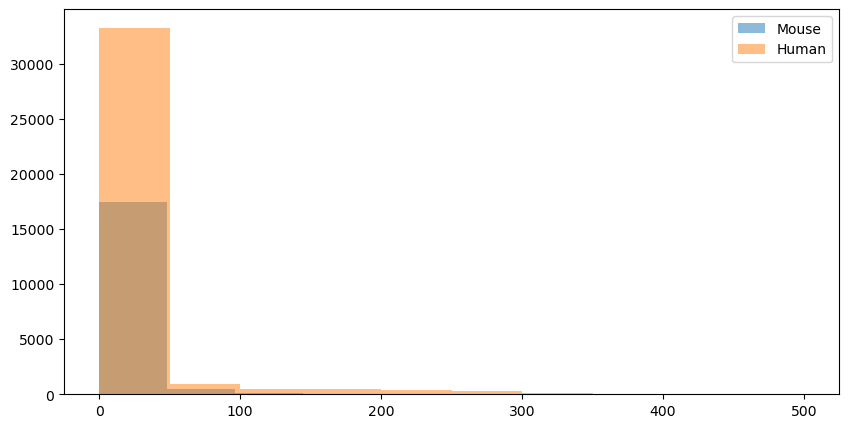

In [3]:
# For these conserved genes / orthologes let's summarize the inron lengths (via splice junction lengths)
mouse_atse["intron_length"] = (mouse_atse["end"] - mouse_atse["start"]) / 1000
human_atse["intron_length"] = (human_atse["end"] - human_atse["start"]) / 1000

# Add percentile to mouse_atse and human_atse based on total_score 
mouse_atse["total_score_percentile"] = mouse_atse["total_score"].rank(pct=True)
human_atse["total_score_percentile"] = human_atse["total_score"].rank(pct=True)

# Let's plot dsitribution of intron length for mouse and human
plt.figure(figsize=(10, 5))
plt.hist(mouse_atse["intron_length"], bins=10, alpha=0.5, label="Mouse")
plt.hist(human_atse["intron_length"], bins=10, alpha=0.5, label="Human")
plt.legend()
plt.show()


In [4]:
mouse_atse[["total_score", "total_score_percentile"]]


,total_score,total_score_percentile
4,9085,0.123963
5,12426,0.179052
6,369590,0.804196
7,750246,0.893832
8,9108,0.124650
...,...,...
30070,21306,0.285165
30071,14556,0.209809
30075,4352,0.030071
30076,5674,0.057121


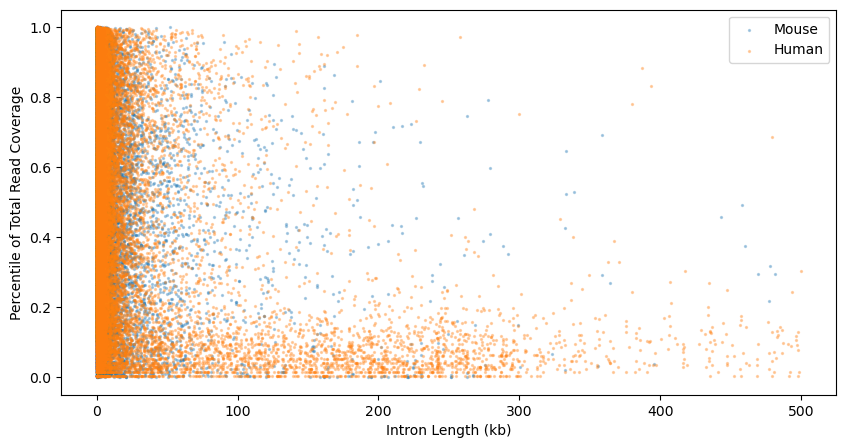

In [5]:
# plot correlation between normalized_total_score and intron_length
plt.figure(figsize=(10, 5))
plt.scatter(mouse_atse["intron_length"], mouse_atse["total_score_percentile"], alpha=0.3, label="Mouse", s=2)
plt.scatter(human_atse["intron_length"], human_atse["total_score_percentile"], alpha=0.3, label="Human", s=2)
plt.legend()
plt.xlabel("Intron Length (kb)")
plt.ylabel("Percentile of Total Read Coverage")
plt.show()


In [7]:
paths['results']

'/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results'

In [9]:
# Load human file (converted from mm10)
human_lifted_over = pd.read_csv(os.path.join(paths['results'], "hglft_genome_33e5d0_490380.bed"), sep="\t", header=None)
mouse_bed = pd.read_csv(os.path.join(paths['results'], "mouse_junctions_mm10.bed"), sep="\t", header=None)

=== Junction Conservation Analysis (50,000bp window) ===
Loading all BED files...
Original mouse junctions: 18,207
Original human junctions: 36,013
Mouse lifted to human: 20,859
Human lifted to mouse: 46,135
Finding matches within 50,000bp window for Mouse→Human...
Parsing lifted junction info...
Parsing target junction info...
Chromosome analysis:
  Lifted chromosomes: 27 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr14_GL000225v1_random', 'chr14_KI270722v1_random', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrUn_KI270752v1', 'chrX', 'chrY'])
  Target chromosomes: 24 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY'])
  Common chromosomes: 24 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'c

Mouse→Human matching (50,000bp window): 100%|██████████| 20859/20859 [00:43<00:00, 485.00it/s]


Finding matches within 50,000bp window for Human→Mouse...
Parsing lifted junction info...
Parsing target junction info...
Chromosome analysis:
  Lifted chromosomes: 24 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrUn_GL456382', 'chrUn_JH584304', 'chrX', 'chrY'])
  Target chromosomes: 21 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY'])
  Common chromosomes: 21 (['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY'])
  Missing in target: ['chrM', 'chrUn_GL456382', 'chrUn_JH584304']


Human→Mouse matching (50,000bp window): 100%|██████████| 46135/46135 [02:01<00:00, 380.09it/s]



=== Mouse→Human Conservation Summary ===
Total junctions analyzed: 20,859
Matches found: 16,289 (78.1%)

Match type breakdown:
  distant_match: 11,292 (54.1%)
  no_match_in_window: 4,559 (21.9%)
  perfect_match: 4,537 (21.8%)
  acceptable_match: 229 (1.1%)
  good_match: 208 (1.0%)
  excellent_match: 23 (0.1%)
  chromosome_not_found: 11 (0.1%)

Distance statistics for 16,289 matches:
  Mean total distance: 11957.8 bp
  Median total distance: 3425.0 bp
  Max total distance: 98831 bp

Distance distribution:
  Perfect (0 bp): 4,537 (27.9%)
  Excellent (1-2 bp): 23 (0.1%)
  Good (3-10 bp): 208 (1.3%)
  Acceptable (11-50 bp): 229 (1.4%)
  Distant (>50 bp): 11,292 (69.3%)

Gene-level statistics (using Ensembl IDs when available):
  Total genes: 7,336
  Genes with conserved junctions: 6,754 (92.1%)
  Junctions with Ensembl IDs: 0 (0.0%)

=== Human→Mouse Conservation Summary ===
Total junctions analyzed: 46,135
Matches found: 30,937 (67.1%)

Match type breakdown:
  distant_match: 26,007 (56.4%

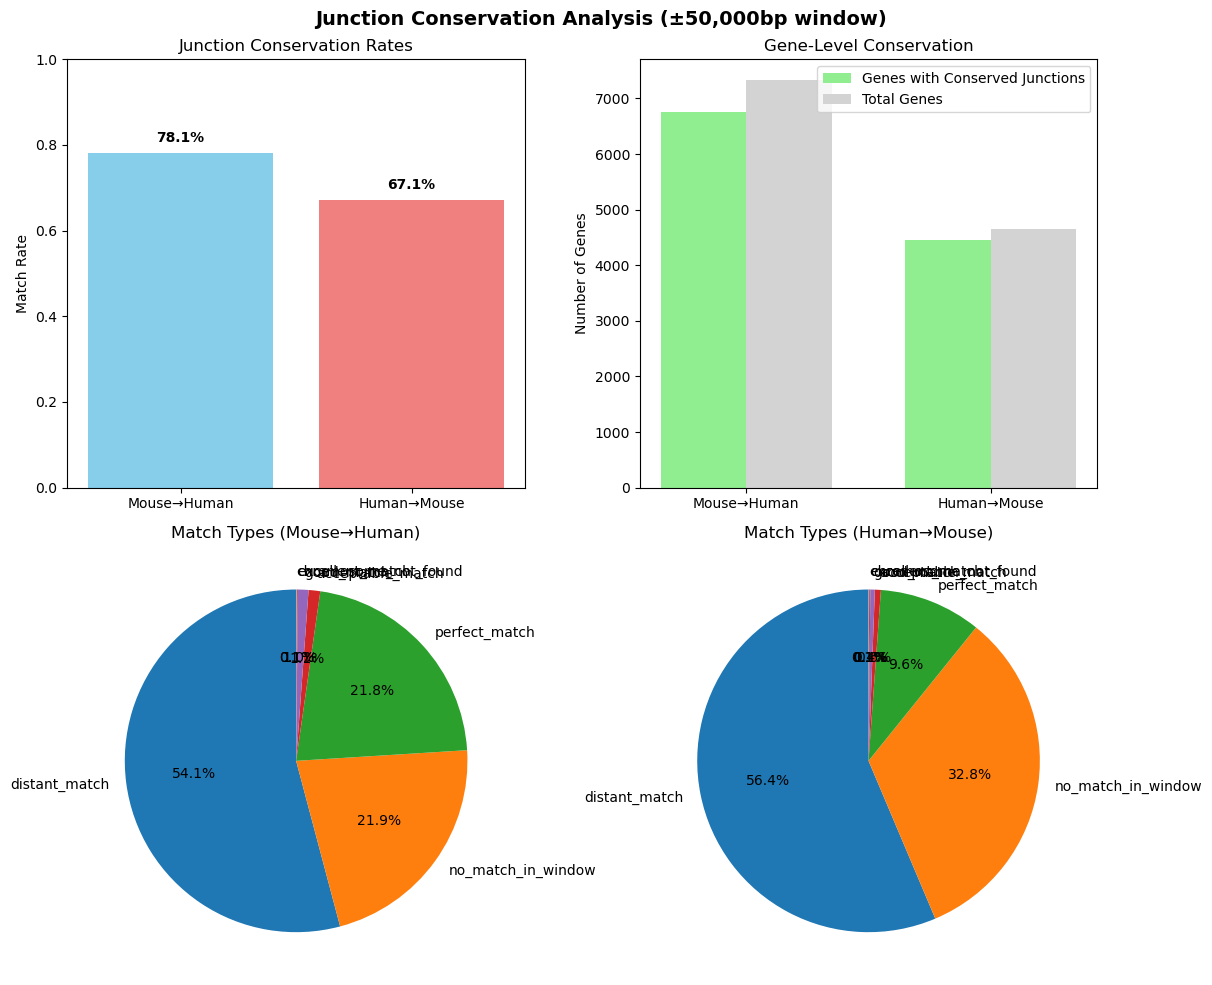


=== Results Saved ===
Mouse→Human: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/conservation_mouse_to_human_50000bp.csv
Human→Mouse: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/conservation_human_to_mouse_50000bp.csv

Conservation analysis complete with 1000bp window!


In [10]:
# Improved conservation analysis using Ensembl IDs and configurable window
import pandas as pd
import numpy as np
from collections import defaultdict
from tqdm import tqdm

def load_all_bed_files():
    """Load all BED files for bidirectional analysis."""
    
    print("Loading all BED files...")
    
    # Original files
    mouse_bed = pd.read_csv(
        os.path.join(paths['results'], "mouse_junctions_mm10.bed"), 
        sep="\t", header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    human_bed = pd.read_csv(
        os.path.join(paths['results'], "human_junctions_hg38.bed"), 
        sep="\t", header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    # Lifted files
    mouse_lifted_to_human = pd.read_csv(
        os.path.join(paths['results'], "hglft_genome_15625e_48a990.bed"), 
        sep="\t", header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    human_lifted_to_mouse = pd.read_csv(
        os.path.join(paths['results'], "hglft_genome_33e5d0_490380.bed"), 
        sep="\t", header=None,
        names=['chrom', 'start', 'end', 'name', 'score', 'strand']
    )
    
    print(f"Original mouse junctions: {len(mouse_bed):,}")
    print(f"Original human junctions: {len(human_bed):,}")
    print(f"Mouse lifted to human: {len(mouse_lifted_to_human):,}")
    print(f"Human lifted to mouse: {len(human_lifted_to_mouse):,}")
    
    return mouse_bed, human_bed, mouse_lifted_to_human, human_lifted_to_mouse

def extract_junction_info_with_ensembl(name):
    """
    Extract junction info from BED name field, prioritizing Ensembl IDs.
    Format: chr_start_end_strand_geneName_eventID_ensemblID (or variations)
    """
    parts = name.split('_')
    
    if len(parts) >= 4:
        junction_id = '_'.join(parts[:4])  # chr_start_end_strand
        
        # Look for Ensembl gene ID (starts with ENSMUSG or ENSG)
        ensembl_id = None
        gene_name = 'Unknown'
        event_id = 'Unknown'
        
        for part in parts[4:]:
            if part.startswith('ENSMUSG') or part.startswith('ENSG'):
                ensembl_id = part
            elif part.startswith('ATSE_') or part.startswith('ENSG') or part.startswith('ENSMUSG'):
                event_id = part
            elif part not in ['Unknown', ''] and not part.startswith('ENS'):
                gene_name = part
        
        # If we found an Ensembl ID, use it as the primary identifier
        primary_gene_id = ensembl_id if ensembl_id else gene_name
        
        return junction_id, gene_name, event_id, ensembl_id, primary_gene_id
    else:
        return name, 'Unknown', 'Unknown', None, 'Unknown'

def find_matches_within_window(lifted_bed, target_bed, window_size=100, direction_name=""):
    """
    Find matches within a specified window size using Ensembl IDs when available.
    
    Args:
        lifted_bed: Lifted junction coordinates
        target_bed: Target junction coordinates to match against
        window_size: Maximum distance to consider a match (bp)
        direction_name: Name for progress tracking
        
    Returns:
        DataFrame with match results
    """
    
    print(f"Finding matches within {window_size:,}bp window for {direction_name}...")
    
    # Parse junction info for both datasets
    lifted_bed = lifted_bed.copy()
    target_bed = target_bed.copy()
    
    print("Parsing lifted junction info...")
    lifted_info = lifted_bed['name'].apply(extract_junction_info_with_ensembl)
    lifted_bed['junction_id'] = [x[0] for x in lifted_info]
    lifted_bed['gene_name'] = [x[1] for x in lifted_info] 
    lifted_bed['event_id'] = [x[2] for x in lifted_info]
    lifted_bed['ensembl_id'] = [x[3] for x in lifted_info]
    lifted_bed['primary_gene_id'] = [x[4] for x in lifted_info]
    
    print("Parsing target junction info...")
    target_info = target_bed['name'].apply(extract_junction_info_with_ensembl)
    target_bed['junction_id'] = [x[0] for x in target_info]
    target_bed['gene_name'] = [x[1] for x in target_info]
    target_bed['event_id'] = [x[2] for x in target_info]
    target_bed['ensembl_id'] = [x[3] for x in target_info]
    target_bed['primary_gene_id'] = [x[4] for x in target_info]
    
    # Check chromosome overlap
    lifted_chroms = set(lifted_bed['chrom'])
    target_chroms = set(target_bed['chrom'])
    common_chroms = lifted_chroms.intersection(target_chroms)
    missing_chroms = lifted_chroms - target_chroms
    
    print(f"Chromosome analysis:")
    print(f"  Lifted chromosomes: {len(lifted_chroms)} ({sorted(lifted_chroms)})")
    print(f"  Target chromosomes: {len(target_chroms)} ({sorted(target_chroms)})")
    print(f"  Common chromosomes: {len(common_chroms)} ({sorted(common_chroms)})")
    if missing_chroms:
        print(f"  Missing in target: {sorted(missing_chroms)}")
    
    # Group target junctions by chromosome for efficient lookup
    target_by_chrom = defaultdict(list)
    for idx, row in target_bed.iterrows():
        target_by_chrom[row['chrom']].append({
            'start': row['start'],
            'end': row['end'],
            'strand': row['strand'],
            'junction_id': row['junction_id'],
            'gene_name': row['gene_name'],
            'event_id': row['event_id'],
            'ensembl_id': row['ensembl_id'],
            'primary_gene_id': row['primary_gene_id'],
            'name': row['name']
        })
    
    results = []
    
    for idx, lifted_row in tqdm(lifted_bed.iterrows(), total=len(lifted_bed), 
                               desc=f"{direction_name} matching ({window_size:,}bp window)"):
        
        lifted_chrom = lifted_row['chrom']
        lifted_start = lifted_row['start']
        lifted_end = lifted_row['end']
        lifted_strand = lifted_row['strand']
        
        # Basic info
        result = {
            'lifted_junction_id': lifted_row['junction_id'],
            'lifted_gene_name': lifted_row['gene_name'],
            'lifted_ensembl_id': lifted_row['ensembl_id'],
            'lifted_primary_gene_id': lifted_row['primary_gene_id'],
            'lifted_event_id': lifted_row['event_id'],
            'lifted_coords': f"{lifted_chrom}:{lifted_start}-{lifted_end}",
            'lifted_strand': lifted_strand
        }
        
        # Check if chromosome exists in target
        if lifted_chrom not in target_by_chrom:
            result.update({
                'match_found': False,
                'match_type': 'chromosome_not_found',
                'target_junction_id': None,
                'target_gene_name': None,
                'target_ensembl_id': None,
                'target_primary_gene_id': None,
                'target_event_id': None,
                'start_distance': None,
                'end_distance': None,
                'total_distance': None,
                'explanation': f"Chromosome {lifted_chrom} not found in target dataset"
            })
            results.append(result)
            continue
        
        # Find best match within window
        best_match = None
        min_distance = float('inf')
        
        for target_junction in target_by_chrom[lifted_chrom]:
            
            # Check strand if specified
            if (lifted_strand != '.' and target_junction['strand'] != '.' and 
                lifted_strand != target_junction['strand']):
                continue
            
            # Calculate distances
            start_dist = abs(lifted_start - target_junction['start'])
            end_dist = abs(lifted_end - target_junction['end'])
            total_dist = start_dist + end_dist
            
            # Check if within window
            if start_dist <= window_size and end_dist <= window_size:
                if total_dist < min_distance:
                    min_distance = total_dist
                    best_match = {
                        'junction_id': target_junction['junction_id'],
                        'gene_name': target_junction['gene_name'],
                        'ensembl_id': target_junction['ensembl_id'],
                        'primary_gene_id': target_junction['primary_gene_id'],
                        'event_id': target_junction['event_id'],
                        'start_distance': start_dist,
                        'end_distance': end_dist,
                        'total_distance': total_dist
                    }
        
        if best_match:
            # Classify match quality
            if best_match['total_distance'] == 0:
                match_type = 'perfect_match'
            elif best_match['total_distance'] <= 2:
                match_type = 'excellent_match'
            elif best_match['total_distance'] <= 10:
                match_type = 'good_match'
            elif best_match['total_distance'] <= 50:
                match_type = 'acceptable_match'
            else:
                match_type = 'distant_match'
            
            result.update({
                'match_found': True,
                'match_type': match_type,
                'target_junction_id': best_match['junction_id'],
                'target_gene_name': best_match['gene_name'],
                'target_ensembl_id': best_match['ensembl_id'],
                'target_primary_gene_id': best_match['primary_gene_id'],
                'target_event_id': best_match['event_id'],
                'start_distance': best_match['start_distance'],
                'end_distance': best_match['end_distance'],
                'total_distance': best_match['total_distance'],
                'explanation': f"Match found with {best_match['total_distance']}bp total distance"
            })
        else:
            result.update({
                'match_found': False,
                'match_type': 'no_match_in_window',
                'target_junction_id': None,
                'target_gene_name': None,
                'target_ensembl_id': None,
                'target_primary_gene_id': None,
                'target_event_id': None,
                'start_distance': None,
                'end_distance': None,
                'total_distance': None,
                'explanation': f"No match found within {window_size}bp window on {lifted_chrom}"
            })
        
        results.append(result)
    
    return pd.DataFrame(results)

def summarize_conservation_results(results_df, direction_name):
    """Summarize conservation results with gene-level analysis."""
    
    print(f"\n=== {direction_name} Conservation Summary ===")
    
    # Overall statistics
    total_junctions = len(results_df)
    matches_found = results_df['match_found'].sum()
    match_rate = matches_found / total_junctions
    
    print(f"Total junctions analyzed: {total_junctions:,}")
    print(f"Matches found: {matches_found:,} ({match_rate:.1%})")
    
    # Match type breakdown
    match_type_counts = results_df['match_type'].value_counts()
    print(f"\nMatch type breakdown:")
    for match_type, count in match_type_counts.items():
        percentage = (count / total_junctions) * 100
        print(f"  {match_type}: {count:,} ({percentage:.1f}%)")
    
    # Distance statistics for matches
    matches_with_distances = results_df[results_df['total_distance'].notna()]
    if len(matches_with_distances) > 0:
        print(f"\nDistance statistics for {len(matches_with_distances):,} matches:")
        print(f"  Mean total distance: {matches_with_distances['total_distance'].mean():.1f} bp")
        print(f"  Median total distance: {matches_with_distances['total_distance'].median():.1f} bp")
        print(f"  Max total distance: {matches_with_distances['total_distance'].max():.0f} bp")
        
        # Distance distribution
        distance_ranges = [
            (0, 0, "Perfect (0 bp)"),
            (1, 2, "Excellent (1-2 bp)"),
            (3, 10, "Good (3-10 bp)"),
            (11, 50, "Acceptable (11-50 bp)"),
            (51, float('inf'), "Distant (>50 bp)")
        ]
        
        print(f"\nDistance distribution:")
        for min_dist, max_dist, label in distance_ranges:
            if max_dist == 0:
                count = (matches_with_distances['total_distance'] == 0).sum()
            elif max_dist == float('inf'):
                count = (matches_with_distances['total_distance'] >= min_dist).sum()
            else:
                count = ((matches_with_distances['total_distance'] >= min_dist) & 
                        (matches_with_distances['total_distance'] <= max_dist)).sum()
            if count > 0:
                percentage = (count / len(matches_with_distances)) * 100
                print(f"  {label}: {count:,} ({percentage:.1f}%)")
    
    # Gene-level statistics using primary gene ID (Ensembl when available)
    genes_with_matches = results_df[results_df['match_found']]['lifted_primary_gene_id'].nunique()
    total_genes = results_df['lifted_primary_gene_id'].nunique()
    gene_match_rate = genes_with_matches / total_genes if total_genes > 0 else 0
    
    print(f"\nGene-level statistics (using Ensembl IDs when available):")
    print(f"  Total genes: {total_genes:,}")
    print(f"  Genes with conserved junctions: {genes_with_matches:,} ({gene_match_rate:.1%})")
    
    # Show examples of Ensembl ID usage
    ensembl_count = results_df['lifted_ensembl_id'].notna().sum()
    print(f"  Junctions with Ensembl IDs: {ensembl_count:,} ({ensembl_count/total_junctions:.1%})")
    
    return {
        'total_junctions': total_junctions,
        'matches_found': matches_found,
        'match_rate': match_rate,
        'match_type_counts': match_type_counts,
        'genes_with_matches': genes_with_matches,
        'total_genes': total_genes,
        'gene_match_rate': gene_match_rate
    }

def create_conservation_plot(mouse_results, human_results, window_size):
    """Create visualization of conservation results (PDF only)."""
    
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Junction Conservation Analysis (±{window_size:,}bp window)', fontsize=14, fontweight='bold')
    
    # Plot 1: Match rates comparison
    ax1 = axes[0, 0]
    directions = ['Mouse→Human', 'Human→Mouse']
    match_rates = [mouse_results['match_rate'], human_results['match_rate']]
    
    bars = ax1.bar(directions, match_rates, color=['skyblue', 'lightcoral'])
    ax1.set_title('Junction Conservation Rates')
    ax1.set_ylabel('Match Rate')
    ax1.set_ylim(0, 1)
    
    # Add percentage labels
    for bar, rate in zip(bars, match_rates):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Gene-level conservation
    ax2 = axes[0, 1]
    gene_data = {
        'Direction': ['Mouse→Human', 'Human→Mouse'],
        'Genes with Matches': [mouse_results['genes_with_matches'], human_results['genes_with_matches']],
        'Total Genes': [mouse_results['total_genes'], human_results['total_genes']]
    }
    
    x = range(len(gene_data['Direction']))
    width = 0.35
    
    ax2.bar([i - width/2 for i in x], gene_data['Genes with Matches'], width, 
           label='Genes with Conserved Junctions', color='lightgreen')
    ax2.bar([i + width/2 for i in x], gene_data['Total Genes'], width,
           label='Total Genes', color='lightgray')
    
    ax2.set_title('Gene-Level Conservation')
    ax2.set_ylabel('Number of Genes')
    ax2.set_xticks(x)
    ax2.set_xticklabels(gene_data['Direction'])
    ax2.legend()
    
    # Plot 3: Match types (mouse to human)
    ax3 = axes[1, 0]
    mouse_match_types = mouse_results['match_type_counts']
    if len(mouse_match_types) > 0:
        ax3.pie(mouse_match_types.values, labels=mouse_match_types.index, autopct='%1.1f%%', startangle=90)
        ax3.set_title('Match Types (Mouse→Human)')
    
    # Plot 4: Match types (human to mouse)
    ax4 = axes[1, 1]
    human_match_types = human_results['match_type_counts']
    if len(human_match_types) > 0:
        ax4.pie(human_match_types.values, labels=human_match_types.index, autopct='%1.1f%%', startangle=90)
        ax4.set_title('Match Types (Human→Mouse)')
    
    plt.tight_layout()
    
    # Save plot (PDF only)
    plot_path = os.path.join(paths['figures'], f"{datetime.now().strftime('%H%M%S')}_conservation_analysis_{window_size}bp.pdf")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    
    print(f"Conservation plot saved: {plot_path}")
    plt.show()

# Run the improved analysis
def run_conservation_analysis(window_size=1000):
    """Run conservation analysis with specified window size."""
    
    print(f"=== Junction Conservation Analysis ({window_size:,}bp window) ===")
    
    # Load all BED files
    mouse_bed, human_bed, mouse_lifted_to_human, human_lifted_to_mouse = load_all_bed_files()
    
    # Analyze mouse to human conservation
    mouse_to_human_results = find_matches_within_window(
        mouse_lifted_to_human, human_bed, window_size=window_size, direction_name="Mouse→Human"
    )
    
    # Analyze human to mouse conservation
    human_to_mouse_results = find_matches_within_window(
        human_lifted_to_mouse, mouse_bed, window_size=window_size, direction_name="Human→Mouse"
    )
    
    # Summarize results
    mouse_summary = summarize_conservation_results(mouse_to_human_results, "Mouse→Human")
    human_summary = summarize_conservation_results(human_to_mouse_results, "Human→Mouse")
    
    # Create visualization
    create_conservation_plot(mouse_summary, human_summary, window_size)
    
    # Save detailed results
    mouse_to_human_path = os.path.join(paths['results'], f"conservation_mouse_to_human_{window_size}bp.csv")
    mouse_to_human_results.to_csv(mouse_to_human_path, index=False)
    
    human_to_mouse_path = os.path.join(paths['results'], f"conservation_human_to_mouse_{window_size}bp.csv")
    human_to_mouse_results.to_csv(human_to_mouse_path, index=False)
    
    print(f"\n=== Results Saved ===")
    print(f"Mouse→Human: {mouse_to_human_path}")
    print(f"Human→Mouse: {human_to_mouse_path}")
    
    return mouse_to_human_results, human_to_mouse_results, mouse_summary, human_summary

# Run with variable window size
window_size=50000
mouse_results = f"mouse_results_{window_size}"
human_results = f"human_results_{window_size}"
mouse_summary = f"mouse_summary_{window_size}"
human_summary = f"human_summary_{window_size}"

# Then assign the results
mouse_results, human_results, mouse_summary, human_summary = run_conservation_analysis(window_size=window_size)
print("\nConservation analysis complete with 1000bp window!")

In [11]:
# Simplified sequence-based validation of conserved splice junctions
from Bio import pairwise2
from Bio.Seq import Seq
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from datetime import datetime

def extract_splice_sequences(chrom, start, end, strand, genome_fasta, exon_length=250):
    """
    Extract sequences around splice sites with proper strand orientation.
    Returns donor and acceptor sequences in transcript orientation.
    """
    
    try:
        if strand == '+':
            # For + strand: donor at start (GT), acceptor at end (AG)
            donor_seq = genome_fasta[chrom][max(0, start - exon_length):start + 2].seq
            acceptor_seq = genome_fasta[chrom][end - 2:end + exon_length].seq
            donor_motif = str(genome_fasta[chrom][start:start + 2].seq)
            acceptor_motif = str(genome_fasta[chrom][end - 2:end].seq)
            
        else:  # strand == '-'
            # For - strand: flip coordinates and reverse complement
            donor_seq = str(Seq(genome_fasta[chrom][end - 2:end + exon_length].seq).reverse_complement())
            acceptor_seq = str(Seq(genome_fasta[chrom][max(0, start - exon_length):start + 2].seq).reverse_complement())
            donor_motif = str(Seq(genome_fasta[chrom][end - 2:end].seq).reverse_complement())
            acceptor_motif = str(Seq(genome_fasta[chrom][start:start + 2].seq).reverse_complement())
        
        return {
            'donor_seq': str(donor_seq),
            'acceptor_seq': str(acceptor_seq),
            'donor_motif': donor_motif,
            'acceptor_motif': acceptor_motif,
            'success': True
        }
        
    except Exception as e:
        return {
            'donor_seq': None,
            'acceptor_seq': None,
            'donor_motif': None,
            'acceptor_motif': None,
            'success': False,
            'error': str(e)
        }

def calculate_sequence_metrics(seq1, seq2):
    """Calculate both identity and similarity between two sequences."""
    
    if not seq1 or not seq2:
        return {'identity': 0.0, 'similarity': 0.0}
    
    try:
        # Simple global alignment
        alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
        
        if not alignments:
            return {'identity': 0.0, 'similarity': 0.0}
        
        aligned_seq1, aligned_seq2, score, start, end = alignments[0]
        
        # Calculate identity (exact matches only)
        matches = sum(c1 == c2 for c1, c2 in zip(aligned_seq1, aligned_seq2) 
                     if c1 != '-' and c2 != '-')
        
        # Calculate similarity (transitions get partial credit)
        transitions = {'A': 'G', 'G': 'A', 'C': 'T', 'T': 'C'}
        similarity_score = 0
        valid_positions = 0
        
        for c1, c2 in zip(aligned_seq1, aligned_seq2):
            if c1 != '-' and c2 != '-':
                valid_positions += 1
                if c1 == c2:
                    similarity_score += 1.0  # Perfect match
                elif transitions.get(c1) == c2:
                    similarity_score += 0.5  # Transition
                # Transversions get 0 points
        
        total_positions = max(len(seq1), len(seq2))
        identity = matches / total_positions if total_positions > 0 else 0.0
        similarity = similarity_score / total_positions if total_positions > 0 else 0.0
        
        return {'identity': identity, 'similarity': similarity}
        
    except:
        return {'identity': 0.0, 'similarity': 0.0}

def check_splice_motifs(motif1, motif2):
    """Check if splice motifs are canonical and conserved."""
    
    canonical_donors = {'GT', 'GC'}
    canonical_acceptor = {'AG'}
    
    # Check if both are canonical
    is_canonical = (motif1 in canonical_donors or motif1 in canonical_acceptor) and \
                   (motif2 in canonical_donors or motif2 in canonical_acceptor)
    
    # Check if conserved
    is_conserved = motif1 == motif2
    
    return is_canonical and is_conserved

def validate_splice_junctions(conservation_results, source_genome, target_genome):
    """
    Simple validation focusing on:
    1. Exonic sequence conservation around splice sites
    2. Splice motif conservation (GT-AG, GC-AG)
    """
    
    print(f"Validating {len(conservation_results)} splice junctions...")
    
    # Filter for coordinate matches
    matched = conservation_results[conservation_results['match_found'] == True].copy()
    
    if len(matched) == 0:
        print("No matched junctions to validate")
        return pd.DataFrame()
    
    print(f"Analyzing {len(matched)} coordinate-matched junctions...")
    
    results = []
    
    for idx, row in tqdm(matched.iterrows(), total=len(matched), desc="Sequence validation"):
        
        try:
            # Parse coordinates
            source_parts = row['lifted_junction_id'].split('_')
            source_chrom, source_start, source_end, source_strand = \
                source_parts[0], int(source_parts[1]), int(source_parts[2]), source_parts[3]
            
            target_parts = row['target_junction_id'].split('_')
            target_chrom, target_start, target_end, target_strand = \
                target_parts[0], int(target_parts[1]), int(target_parts[2]), target_parts[3]
            
            # Extract sequences
            source_seqs = extract_splice_sequences(
                source_chrom, source_start, source_end, source_strand, source_genome
            )
            target_seqs = extract_splice_sequences(
                target_chrom, target_start, target_end, target_strand, target_genome
            )
            
            if not (source_seqs['success'] and target_seqs['success']):
                continue
            
            # Calculate sequence conservation (both identity and similarity)
            donor_metrics = calculate_sequence_metrics(
                source_seqs['donor_seq'], target_seqs['donor_seq']
            )
            acceptor_metrics = calculate_sequence_metrics(
                source_seqs['acceptor_seq'], target_seqs['acceptor_seq']
            )
            
            # Average metrics
            average_identity = (donor_metrics['identity'] + acceptor_metrics['identity']) / 2
            average_similarity = (donor_metrics['similarity'] + acceptor_metrics['similarity']) / 2
            
            # Check splice motif conservation
            donor_motifs_ok = check_splice_motifs(
                source_seqs['donor_motif'], target_seqs['donor_motif']
            )
            acceptor_motifs_ok = check_splice_motifs(
                source_seqs['acceptor_motif'], target_seqs['acceptor_motif']
            )
            both_motifs_ok = donor_motifs_ok and acceptor_motifs_ok
            
            # Simple classification
            if average_identity >= 0.6 and both_motifs_ok:
                validation = 'conserved'
            elif average_identity >= 0.6:
                validation = 'sequence_only'
            elif both_motifs_ok:
                validation = 'motifs_only'
            else:
                validation = 'diverged'
            
            results.append({
                'junction_index': idx,
                'source_junction': row['lifted_junction_id'],
                'target_junction': row['target_junction_id'],
                'source_gene': row['lifted_primary_gene_id'],
                'target_gene': row['target_primary_gene_id'],
                'coordinate_distance': row['total_distance'],
                
                # Sequence conservation
                'donor_identity': donor_metrics['identity'],
                'acceptor_identity': acceptor_metrics['identity'],
                'average_identity': average_identity,
                'donor_similarity': donor_metrics['similarity'],
                'acceptor_similarity': acceptor_metrics['similarity'],
                'average_similarity': average_similarity,
                
                # Splice motifs
                'source_donor_motif': source_seqs['donor_motif'],
                'target_donor_motif': target_seqs['donor_motif'],
                'source_acceptor_motif': source_seqs['acceptor_motif'],
                'target_acceptor_motif': target_seqs['acceptor_motif'],
                'donor_motifs_conserved': donor_motifs_ok,
                'acceptor_motifs_conserved': acceptor_motifs_ok,
                'both_motifs_conserved': both_motifs_ok,
                
                # Overall assessment
                'validation_result': validation,
                'passes_60_percent': average_identity >= 0.6
            })
            
        except Exception as e:
            print(f"Error processing junction {idx}: {e}")
            continue
    
    results_df = pd.DataFrame(results)
    
    # Print simple summary
    print_simple_summary(results_df)
    
    return results_df

def print_simple_summary(results_df):
    """Print straightforward summary of validation results."""
    
    print(f"\n=== Splice Junction Validation Summary ===")
    print(f"Total junctions analyzed: {len(results_df):,}")
    
    if len(results_df) == 0:
        return
    
    # Validation breakdown
    print(f"\nValidation results:")
    validation_counts = results_df['validation_result'].value_counts()
    for result, count in validation_counts.items():
        percentage = (count / len(results_df)) * 100
        print(f"  {result}: {count:,} ({percentage:.1f}%)")
    
    # Key statistics
    mean_identity = results_df['average_identity'].mean()
    mean_similarity = results_df['average_similarity'].mean()
    passes_threshold = results_df['passes_60_percent'].sum()
    both_motifs = results_df['both_motifs_conserved'].sum()
    
    print(f"\nKey metrics:")
    print(f"  Average sequence identity: {mean_identity:.1%}")
    print(f"  Average sequence similarity: {mean_similarity:.1%}")
    print(f"  Junctions ≥60% identity: {passes_threshold:,} ({passes_threshold/len(results_df):.1%})")
    print(f"  Both splice motifs conserved: {both_motifs:,} ({both_motifs/len(results_df):.1%})")
    
    # Distance analysis
    perfect_matches = results_df[results_df['coordinate_distance'] <= 10]
    distant_matches = results_df[results_df['coordinate_distance'] > 1000]
    
    if len(perfect_matches) > 0:
        perfect_identity = perfect_matches['average_identity'].mean()
        perfect_similarity = perfect_matches['average_similarity'].mean()
        print(f"  Perfect coordinate matches (≤10bp): {len(perfect_matches):,} junctions")
        print(f"    - Identity: {perfect_identity:.1%}, Similarity: {perfect_similarity:.1%}")
    
    if len(distant_matches) > 0:
        distant_identity = distant_matches['average_identity'].mean()
        distant_similarity = distant_matches['average_similarity'].mean()
        print(f"  Distant matches (>1000bp): {len(distant_matches):,} junctions")
        print(f"    - Identity: {distant_identity:.1%}, Similarity: {distant_similarity:.1%}")

def create_simple_plots(results_df, output_dir):
    """Create 3 essential plots focusing on the core questions."""
    
    if len(results_df) == 0:
        print("No data to plot")
        return
    
    # Set colorblind-friendly colors
    colors = ['#009E73', '#F0E442', '#0072B2', '#D55E00']  # Green, Yellow, Blue, Orange
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Splice Junction Sequence Validation', fontsize=14, fontweight='bold')
    
    # Plot 1: Coordinate distance vs sequence conservation
    ax1 = axes[0]
    ax1.scatter(results_df['coordinate_distance'], results_df['average_identity'], 
                alpha=0.6, s=20, color=colors[0])
    ax1.axhline(0.6, color=colors[3], linestyle='--', label='60% threshold')
    ax1.set_xlabel('Coordinate Distance (bp)')
    ax1.set_ylabel('Average Sequence Identity')
    ax1.set_title('Distance vs Conservation')
    ax1.set_xscale('log')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Donor vs Acceptor site conservation
    ax2 = axes[1]
    ax2.scatter(results_df['donor_identity'], results_df['acceptor_identity'], 
                alpha=0.6, s=20, color=colors[2])
    ax2.plot([0.4, 1.1], [0.4, 1.1], color=colors[3], linestyle='--', alpha=0.5, label='Equal conservation')
    ax2.axhline(0.6, color='gray', linestyle=':', alpha=0.5)
    ax2.axvline(0.6, color='gray', linestyle=':', alpha=0.5)
    ax2.set_xlabel('Donor Site Identity')
    ax2.set_ylabel('Acceptor Site Identity')
    ax2.set_title('Donor vs Acceptor Conservation')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Validation results distribution
    ax3 = axes[2]
    validation_counts = results_df['validation_result'].value_counts()
    bars = ax3.bar(validation_counts.index, validation_counts.values, 
                   color=colors[:len(validation_counts)])
    ax3.set_ylabel('Number of Junctions')
    ax3.set_title('Validation Results')
    ax3.tick_params(axis='x', rotation=45)
    
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    # Save plot
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    plot_path = os.path.join(output_dir, f"splice_validation_{timestamp}.pdf")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    
    print(f"Validation plots saved: {plot_path}")
    plt.show()
    
    return plot_path

def run_simple_validation(conservation_results, source_genome, target_genome, 
                         direction_name, output_dir):
    """
    Run the simplified validation pipeline.
    """
    
    print(f"\n=== Simple Splice Junction Validation: {direction_name} ===")
    
    # Run validation
    validation_results = validate_splice_junctions(
        conservation_results, source_genome, target_genome
    )
    
    if len(validation_results) > 0:
        # Create plots
        plot_path = create_simple_plots(validation_results, output_dir)
        
        # Save results
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        results_path = os.path.join(output_dir, 
                                  f"validation_{direction_name.lower().replace('→', '_to_')}_{timestamp}.csv")
        validation_results.to_csv(results_path, index=False)
        print(f"Results saved: {results_path}")
        
        # Quick distance analysis
        analyze_distance_conservation(validation_results)
    
    return validation_results

def analyze_distance_conservation(results_df):
    """Quick analysis of how coordinate distance relates to sequence conservation."""
    
    print(f"\n=== Distance vs Conservation Analysis ===")
    
    # Define distance bins
    bins = [0, 10, 100, 1000, float('inf')]
    labels = ['≤10bp', '11-100bp', '101-1000bp', '>1000bp']
    
    results_df['distance_bin'] = pd.cut(results_df['coordinate_distance'], 
                                       bins=bins, labels=labels, right=False)
    
    # Calculate statistics by distance bin
    bin_stats = results_df.groupby('distance_bin').agg({
        'average_identity': ['count', 'mean'],
        'average_similarity': 'mean',
        'both_motifs_conserved': 'mean',
        'passes_60_percent': 'mean'
    }).round(3)
    
    bin_stats.columns = ['count', 'avg_identity', 'avg_similarity', 'motifs_conserved', 'passes_threshold']
    
    print("Distance Bin | Count | Avg Identity | Avg Similarity | Motifs OK | Pass 60%")
    print("-" * 75)
    for distance_bin, row in bin_stats.iterrows():
        print(f"{distance_bin:10} | {row['count']:5.0f} | {row['avg_identity']:11.1%} | "
              f"{row['avg_similarity']:13.1%} | {row['motifs_conserved']:8.1%} | {row['passes_threshold']:7.1%}")
    
    print(f"\nKey insight: High identity + high distance = annotation/assembly differences")
    print(f"These represent the same functional splice sites with different coordinates")

# Main execution
print("Simplified Splice Junction Validation - Ready!")
print("\n" + "="*50)
print("CORE ANALYSIS - 3 MAIN QUESTIONS:")
print("="*50)
print("1. 🧬 Are exonic sequences around splice sites conserved?")
print("2. 🔍 Are splice motifs (GT-AG, GC-AG) preserved?") 
print("3. 📏 Does coordinate distance predict conservation quality?")
print("\nOUTPUT:")
print("• 4 focused plots (distance vs identity, distance vs similarity, identity vs similarity, results)")
print("• Simple validation categories (conserved, diverged, etc.)")
print("• Distance-based quality assessment with both identity and similarity metrics")
print("="*50)
print("\nUsage:")
print("results = run_simple_validation(conservation_results, source_genome,")
print("                                target_genome, direction_name, output_dir)")

Simplified Splice Junction Validation - Ready!

CORE ANALYSIS - 3 MAIN QUESTIONS:
1. 🧬 Are exonic sequences around splice sites conserved?
2. 🔍 Are splice motifs (GT-AG, GC-AG) preserved?
3. 📏 Does coordinate distance predict conservation quality?

OUTPUT:
• 4 focused plots (distance vs identity, distance vs similarity, identity vs similarity, results)
• Simple validation categories (conserved, diverged, etc.)
• Distance-based quality assessment with both identity and similarity metrics

Usage:
results = run_simple_validation(conservation_results, source_genome,
                                target_genome, direction_name, output_dir)



=== Simple Splice Junction Validation: Mouse→Human ===
Validating 20859 splice junctions...
Analyzing 16289 coordinate-matched junctions...


Sequence validation: 100%|██████████| 16289/16289 [28:01<00:00,  9.69it/s] 



=== Splice Junction Validation Summary ===
Total junctions analyzed: 16,289

Validation results:
  conserved: 14,837 (91.1%)
  sequence_only: 725 (4.5%)
  motifs_only: 672 (4.1%)
  diverged: 55 (0.3%)

Key metrics:
  Average sequence identity: 68.8%
  Average sequence similarity: 68.8%
  Junctions ≥60% identity: 15,562 (95.5%)
  Both splice motifs conserved: 15,509 (95.2%)
  Perfect coordinate matches (≤10bp): 4,768 junctions
    - Identity: 80.5%, Similarity: 80.5%
  Distant matches (>1000bp): 10,095 junctions
    - Identity: 63.3%, Similarity: 63.3%
Validation plots saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/splice_validation_20250611_110457.pdf


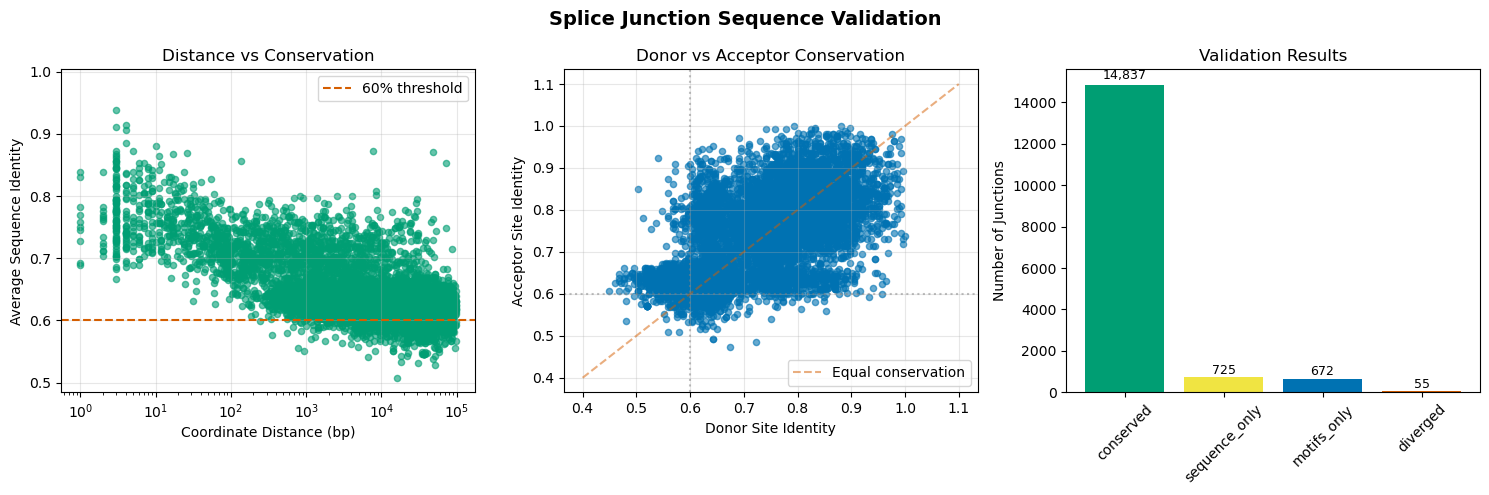

Results saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/validation_mouse_to_human_20250611_110522.csv

=== Distance vs Conservation Analysis ===
Distance Bin | Count | Avg Identity | Avg Similarity | Motifs OK | Pass 60%
---------------------------------------------------------------------------
≤10bp      |  4762 |       80.5% |         80.5% |    99.7% |  100.0%
11-100bp   |   400 |       73.8% |         73.8% |    95.0% |  100.0%
101-1000bp |  1031 |       67.4% |         67.4% |    89.0% |   98.8%
>1000bp    | 10096 |       63.3% |         63.3% |    93.7% |   92.9%

Key insight: High identity + high distance = annotation/assembly differences
These represent the same functional splice sites with different coordinates


/scratch/ipykernel_2944145/1647771663.py:373: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = results_df.groupby('distance_bin').agg({


In [12]:
mouse_validation = run_simple_validation(
    mouse_results, mouse_genome, human_genome,
    'Mouse→Human', paths['results'])

In [13]:
mouse_validation.sort_values(by="average_similarity")

,junction_index,source_junction,target_junction,source_gene,target_gene,coordinate_distance,donor_identity,acceptor_identity,average_identity,donor_similarity,...,source_donor_motif,target_donor_motif,source_acceptor_motif,target_acceptor_motif,donor_motifs_conserved,acceptor_motifs_conserved,both_motifs_conserved,validation_result,passes_60_percent,distance_bin
11392,14715,chr5_90931433_90932911_+,chr4_74144049_74158108_+,4310,ENSG00000163738.19,16178.0,0.480159,0.535714,0.507937,0.480159,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp
14511,18585,chr8_95487676_95488402_-,chr16_58168693_58174450_-,11379,ENSG00000070770.10,51392.0,0.448413,0.607143,0.527778,0.448413,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp
11391,14714,chr5_90931433_90946789_+,chr4_74144049_74158108_+,4310,ENSG00000163738.19,30629.0,0.480159,0.583333,0.531746,0.480159,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp
3152,4064,chr12_32830323_32833031_+,chr7_106284981_106285317_-,6583,ENSG00000105835.13,18227.0,0.559524,0.507937,0.533730,0.559524,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp
10222,13203,chr4_82856984_82859489_-,chr9_14662326_14672829_-,5128,ENSG00000175893.12,48299.0,0.468254,0.607143,0.537698,0.468254,...,GT,GT,AG,AG,True,True,True,motifs_only,False,>1000bp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6753,8813,chr17_90162433_90163791_-,chr2_50053590_50054954_-,10769,ENSG00000179915.25,0.0,0.988095,0.952381,0.970238,0.988095,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp
15930,20336,chrX_41672477_41676339_+,chrX_123483057_123488712_+,11270,ENSG00000125675.20,0.0,0.980159,0.964286,0.972222,0.980159,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp
15929,20335,chrX_41672466_41676339_+,chrX_123483046_123488712_+,11270,ENSG00000125675.20,0.0,0.980159,0.964286,0.972222,0.980159,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp
1210,1682,chr10_63018225_63018759_-,chr10_68337996_68338502_+,3157,ENSG00000096746.18,0.0,0.976190,0.980159,0.978175,0.976190,...,GT,GT,AG,AG,True,True,True,conserved,True,≤10bp


In [14]:
def find_atse_for_junction(junction_id, atse_df):
    """Find ATSE event containing this junction."""
    
    # Parse junction coordinates
    parts = junction_id.split('_')
    chrom, start, end, strand = parts[0], int(parts[1]), int(parts[2]), parts[3]
    
    # Find ATSE event containing this junction
    matching = atse_df[
        (atse_df['chrom'] == chrom) &
        (atse_df['start'] == start) &
        (atse_df['end'] == end) &
        (atse_df['strand'] == strand)
    ]
    
    return matching['event_id'].iloc[0] if len(matching) > 0 else None

def visualize_junction_pair(validation_results, mouse_atse_df, human_atse_df,
                           db_mouse, db_human, output_dir, rank=1):
    """Visualize a conserved junction pair."""
    
    # Get the specified rank junction
    sorted_results = validation_results.sort_values(by="average_similarity", ascending=False)
    junction_data = sorted_results.iloc[rank-1]
    
    print(f"Rank #{rank} Junction:")
    print(f"  Mouse: {junction_data['source_junction']}")
    print(f"  Human: {junction_data['target_junction']}")
    print(f"  Similarity: {junction_data['average_similarity']:.3f}")
    
    # Find ATSE events
    mouse_event = find_atse_for_junction(junction_data['source_junction'], mouse_atse_df)
    human_event = find_atse_for_junction(junction_data['target_junction'], human_atse_df)
    
    # Create output directory
    output_subdir = os.path.join(output_dir, f"junction_rank_{rank}")
    os.makedirs(output_subdir, exist_ok=True)
    
    # Visualize both
    if mouse_event:
        print(f"Visualizing mouse ATSE: {mouse_event}")
        visualize_atse_event(mouse_event, mouse_atse_df, db_mouse,
                           species="mouse", output_dir=output_subdir,
                           padding=5000, show_junc_lines=True)
    
    if human_event:
        print(f"Visualizing human ATSE: {human_event}")
        visualize_atse_event(human_event, human_atse_df, db_human,
                           species="human", output_dir=output_subdir,
                           padding=5000, show_junc_lines=True)
    
    print(f"Results saved to: {output_subdir}")
    return output_subdir

# Usage
print("Simple Junction Visualization - Ready!")
print("Usage:")
print("  visualize_junction_pair(mouse_validation, mouse_atse_df, human_atse_df,")
print("                          db_mouse, db_human, output_dir, rank=1)")

Simple Junction Visualization - Ready!
Usage:
  visualize_junction_pair(mouse_validation, mouse_atse_df, human_atse_df,
                          db_mouse, db_human, output_dir, rank=1)


In [15]:
human_atse[["event_id", "perfect_match_5_prime", "perfect_match_3_prime", "transcripts"]]

,event_id,perfect_match_5_prime,perfect_match_3_prime,transcripts
108,ENSG00000171735.21_atse_4,"s-120531309648273363:e-8509446704651362066,s20...","s-120531309648273363:e-8509446704651362066,s20...",NaN
109,ENSG00000171735.21_atse_4,"s-120531309648273363:e-8509446704651362066,s20...",NaN,NaN
110,ENSG00000171735.21_atse_4,NaN,"s-120531309648273363:e-8509446704651362066,s20...",NaN
111,ENSG00000171735.21_atse_5,NaN,NaN,NaN
112,ENSG00000171735.21_atse_5,NaN,NaN,NaN
...,...,...,...,...
212587,ENSG00000181191.12_atse_1,s1911286747736941067:e1912052390141912842,s1911286747736941067:e1912052390141912842,NaN
212588,ENSG00000127399.15_atse_1,s2962159830469800164:e7905302187544101884,s2962159830469800164:e7905302187544101884,NaN
212589,ENSG00000127399.15_atse_1,s2962159830469800164:e7905302187544101884,NaN,NaN
212590,ENSG00000167775.11_atse_1,NaN,"s-811771966068204897:e-4923689375427743817,s-8...",NaN


In [16]:
# reload atseviz code 
# reload atse_viz code 
import importlib
import atse_viz  # Make sure it's already been imported
importlib.reload(atse_viz)
from atse_viz import *  # Re-import symbols if needed

Visualization imports successful!


Rank #1000 Junction:
  Mouse: chrX_7873953_7874232_+
  Human: chrX_48923295_48923632_-
  Similarity: 0.849
Visualizing mouse ATSE: ATSE_5722
Unique transcripts: ['ENSMUST00000033494.15', 'ENSMUST00000115665.1', 'ENSMUST00000115666.7', 'ENSMUST00000115667.9', 'ENSMUST00000115668.9', 'ENSMUST00000150644.7']
Unique transcripts to remove: []
Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/junction_rank_1000/110526_mouse_Otud5_ATSE_5722.pdf!


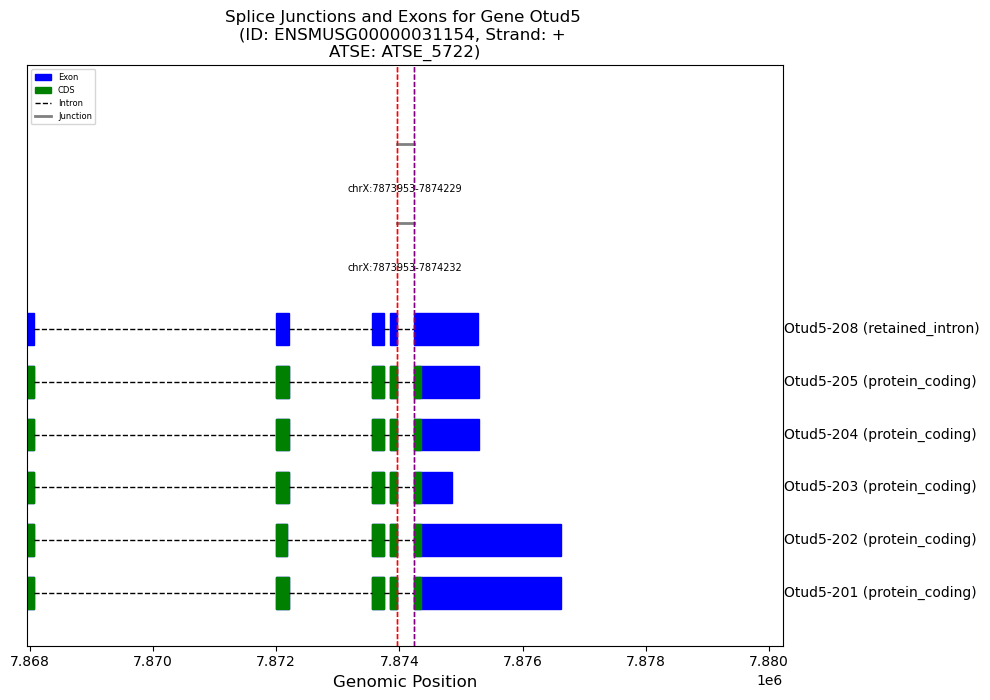

ATSE visualization saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/junction_rank_1000/110526_mouse_Otud5_ATSE_5722.pdf
Visualizing human ATSE: ENSG00000068308.15_atse_5
Unique transcripts: ['ENST00000156084.8', 'ENST00000376488.8', 'ENST00000396743.7', 'ENST00000428668.2']
Unique transcripts to remove: ['s-1352454814075619138:e4621015871437899909', 's-1352454814075619138:e8596328267852976089', 's-1832225669678760862:e-6894307927922662824', 's-1905335901547398624:e2499188566944741144', 's-463544472774772685:e-5316103597889612775', 's-501796323105578555:e-5316103779218819240', 's-501796323125501375:e-5316103779218819240', 's-501796323485772370:e-5316103779228780650', 's-6156901680873856814:e3788185289229491620', 's-6156901681465493939:e-3294622950535666325', 's-6156901681465493939:e3788185289224758523', 's-6156901682634568898:e-3294622950530933228', 's-6156901682634568898:e-3294622950535666325', 's

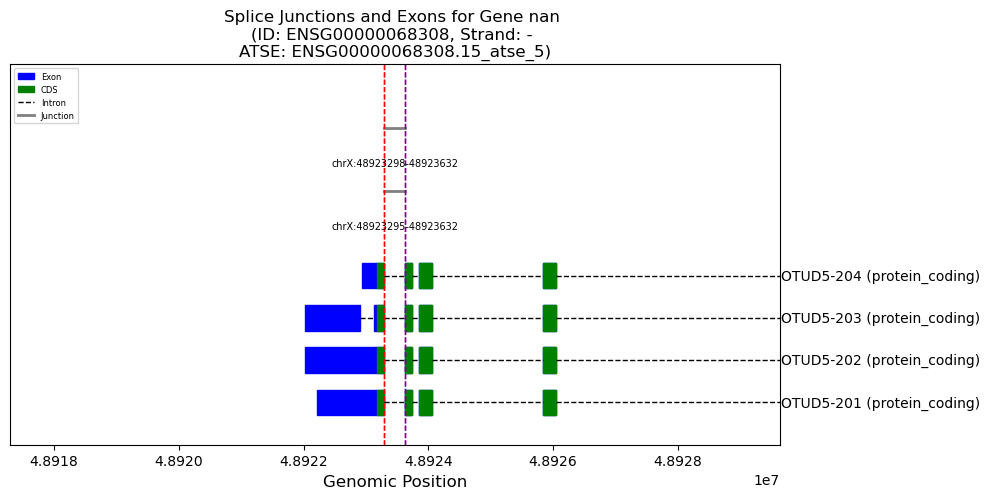

ATSE visualization saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/junction_rank_1000/110532_human_nan_ENSG00000068308.15_atse_5.pdf
Results saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/junction_rank_1000


'/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/cross_species_conservation_analysis_2025-06-11/results/junction_rank_1000'

In [17]:
visualize_junction_pair(mouse_validation, mouse_atse, human_atse,
                          db_mouse, db_human, paths['results'], rank=1000)

In [18]:
mouse_atse[mouse_atse["event_id"] == "ATSE_3157"]

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,transcript_types,annotation_status,perfect_match_5_prime,perfect_match_3_prime,...,position_off_5_prime,position_off_3_prime,Mouse gene stable ID,Mouse gene name,Gene stable ID,Last common ancestor with Mouse,Mouse homology type,Gene name,intron_length,total_score_percentile
7101,ATSE_3157,ENSMUSG00000020069,Hnrnph3,protein_coding,3,exon_skip,"protein_coding,nonsense_mediated_decay",both,"ENSMUST00000020263.13,ENSMUST00000118898.7,ENS...","ENSMUST00000020263.13,ENSMUST00000118898.7",...,1.0,0.0,ENSMUSG00000020069,Hnrnph3,ENSG00000096746,Euarchontoglires,ortholog_one2one,HNRNPH3,0.494,0.890537
7102,ATSE_3157,ENSMUSG00000020069,Hnrnph3,protein_coding,3,exon_skip,"protein_coding,nonsense_mediated_decay",both,"ENSMUST00000020263.13,ENSMUST00000118898.7,ENS...","ENSMUST00000020263.13,ENSMUST00000118898.7,ENS...",...,1.0,0.0,ENSMUSG00000020069,Hnrnph3,ENSG00000096746,Euarchontoglires,ortholog_one2one,HNRNPH3,1.167,0.647498
7103,ATSE_3157,ENSMUSG00000020069,Hnrnph3,protein_coding,3,exon_skip,"protein_coding,nonsense_mediated_decay",both,"ENSMUST00000020263.13,ENSMUST00000118898.7","ENSMUST00000020263.13,ENSMUST00000118898.7,ENS...",...,1.0,0.0,ENSMUSG00000020069,Hnrnph3,ENSG00000096746,Euarchontoglires,ortholog_one2one,HNRNPH3,0.534,0.926786


In [19]:
human_atse[human_atse["event_id"] == "ENSG00000068308.15_atse_5"].iloc[1]

event_id                                                   ENSG00000068308.15_atse_5
gene_id                                                              ENSG00000068308
gene_name                                                                        NaN
gene_types                                                                       NaN
num_junctions                                                                      2
event_type                                                       alternative_3_prime
chromosome                                                                      chrX
strand                                                                             -
atse_start                                                                  48923295
atse_end                                                                    48923632
atse_length                                                                      337
atse_number                                                      